In [1]:
%run ~/analysisLibraries

In [2]:
%matplotlib inline

In [3]:
%load_ext rpy2.ipython

## Read data containing all necessary scores and relevant genes calculated in the previous notebook

In [4]:
adata = sc.read('./write/SDA_object_100comps.h5ad')

component can be changed using the software papermill to execute notebooks in the workflow

In [5]:
comp=0

In [6]:
# Parameters
comp = 98


## Open SDA matrices

In [7]:
A = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/A', sep=' ', header=None)
#B is only for multi-tissues tensor
#B = pd.read_csv('SDA/CELLS_sctransform_onematrix_data/it2000/B1', sep=' ', header=None)
X = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/X1', sep=' ', header=None)

$A$ contains the score of each cell in the components. This score can be used as a "soft clustering" once it is normalized. We will try to do that in the notebook that follows this one. 

In [8]:
A.shape

(10548, 100)

In [9]:
A.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.237044,-0.444741,-0.521709,-0.421176,-0.191632,-0.039443,-0.011519,0.313026,-0.017442,-0.014353,...,-0.713952,0.084345,0.325848,0.577062,-0.704971,-0.307896,0.102466,-0.919935,-0.196817,-1.101270
1,0.411126,-0.113899,-0.404359,-0.412903,0.112982,-0.168036,-0.364643,0.746365,-0.003497,-0.242012,...,0.923655,-0.432896,0.018581,-0.329805,-0.004898,-0.298961,0.290554,0.328762,-0.211422,0.605521
2,-0.554124,-2.115210,0.572701,-0.509780,0.577237,-0.234850,0.450509,0.208679,0.177719,-0.164977,...,-0.382789,0.511820,0.686443,0.116738,-0.315359,-0.109686,1.740900,-0.937221,0.846761,0.562644
3,-0.258430,1.402740,1.303190,-0.759115,1.298820,-0.058847,-0.725280,-0.359907,0.306425,1.195000,...,-0.727815,0.416148,2.020470,-0.108066,-0.465147,-1.716540,0.712520,-0.855888,0.907461,0.266163
4,-0.338097,1.336100,-1.538940,0.907896,0.817900,1.415150,-0.130066,-0.545487,-0.755909,-0.912024,...,-1.259190,-0.325736,0.157799,1.454890,-0.115039,-0.391225,1.149520,0.961979,-0.198099,0.624347


In [10]:
#B

$X$ contains the loading of each gene in each component according to the spike-and-slab prior. The sign of the loading has to be considered together with the sign of the cell score to see if the resulting sign is positive (significant expression of gene) or negative (significant underexpression of gene)

In [11]:
X.columns = adata[:,(np.log(adata.var['variance-Cells'])>0)|(np.log(adata.var['variance-Nuclei']>-1))].var_names

In [12]:
X.shape

(100, 6276)

In [13]:
X.head()

,AURKAIP1,MRPL20,SSU72,LOC469457,GNB1,MORN1,RER1,MMEL1,ACTRT2,CCDC27,...,amplicon-chrX-FAM9A/B/C-6,amplicon-chrX-GAGE10-0,amplicon-chrX-LOC107966365-0,amplicon-chrX-LOC112206844-0,amplicon-chrX-LOC112206844-2,amplicon-chrX-LOC112206844-4,amplicon-chrX-LOC465705-2,amplicon-chrX-PAGE5-3,amplicon-chrX-SPANXN5-2,amplicon-chrX-SSX1/3/2B-15
0,-0.251518,-0.050381,-0.000772,-0.082587,-0.000094,-0.001789,-0.132522,0.000048,-0.053861,-0.035661,...,0.000333,0.000363,-0.000149,-0.036358,-0.000366,0.002521,-0.061503,0.000056,0.000141,0.006134
1,0.000395,0.000193,-0.000607,0.001750,0.000787,-0.001956,-0.000217,-0.000121,0.000535,-0.000017,...,0.066423,-0.000271,0.000069,0.029602,0.001012,0.000030,-0.000178,0.000639,-0.026457,0.000855
2,-0.000250,-0.000108,-0.000195,0.030246,0.000202,-0.001048,-0.000112,0.000151,-0.001854,-0.000145,...,-0.000141,0.001418,-0.000997,-0.000141,-0.039148,-0.000122,0.000968,-0.000012,-0.001109,0.000334
3,0.000423,-0.000399,-0.000322,0.002582,0.000288,0.000177,-0.000765,0.046786,0.000218,0.000263,...,-0.000404,0.000993,0.000137,0.000224,0.043691,-0.000044,0.000219,0.000187,0.000062,-0.000340
4,-0.000056,-0.000013,0.000059,-0.000223,0.033124,-0.000006,0.000276,-0.107145,0.000001,-0.051293,...,-0.034791,0.000032,0.061013,-0.000074,-0.000050,0.000003,0.000006,0.000007,-0.000034,-0.037562


## Some plots and measures about the specific components

#### UMAP of cell scores and batches

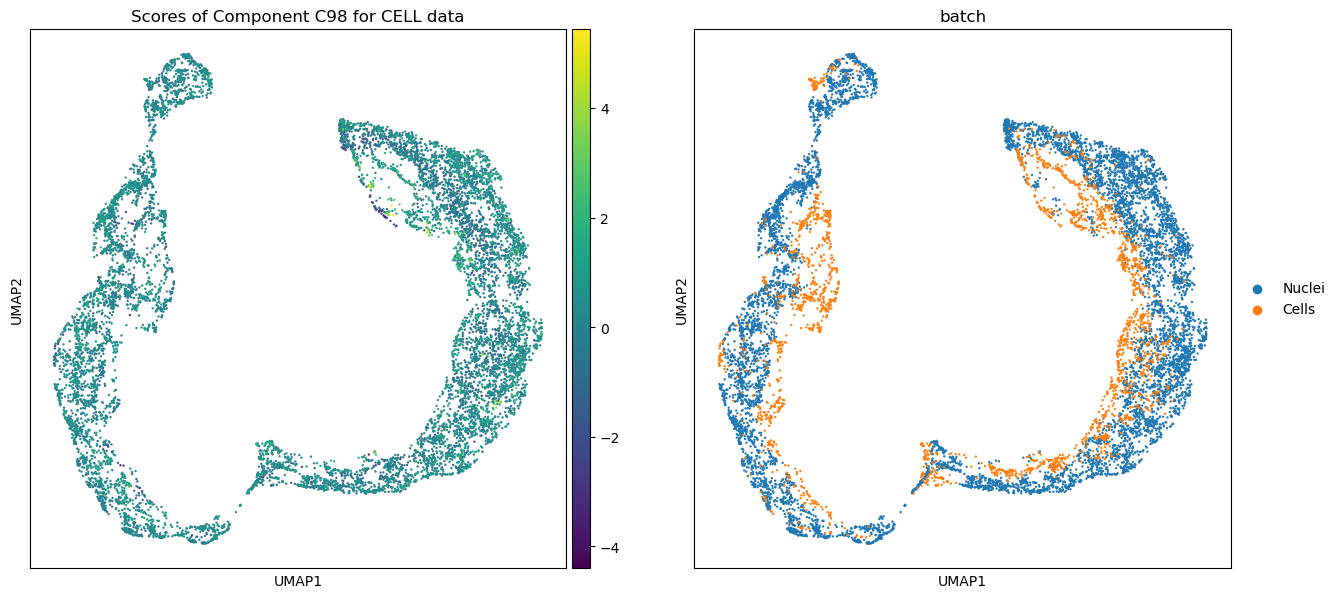

In [14]:
plt.rcParams['figure.figsize']=(7,7)
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}','batch'],
          title=f'Scores of Component C{comp} for CELL data')

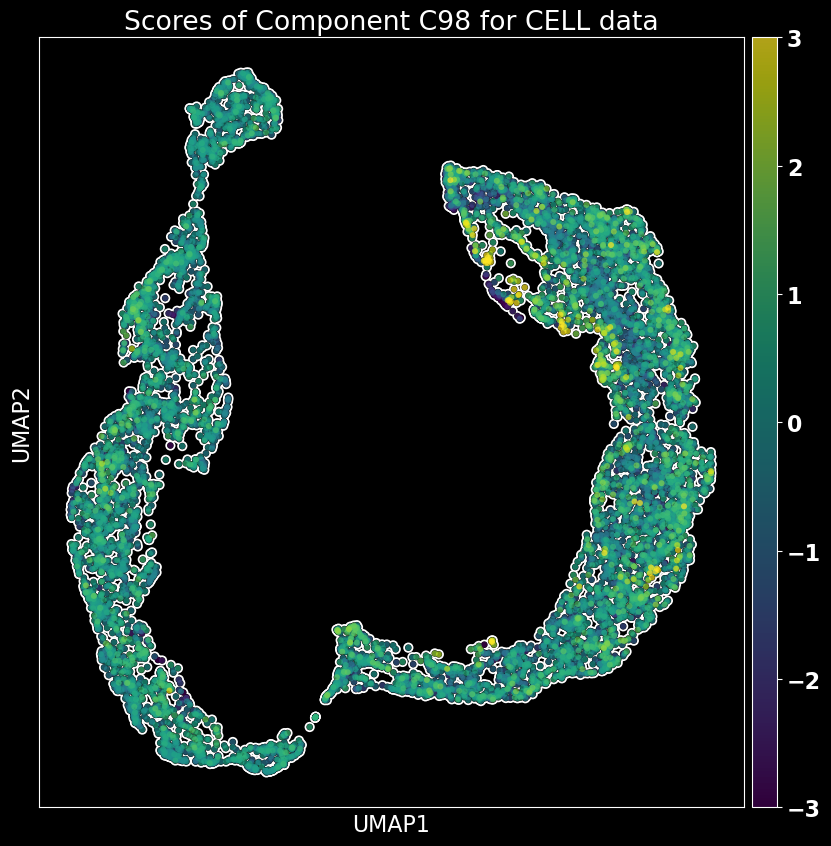

In [15]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True, outline_color=['white','black'],
          save=f'scores_C{comp}_dark.png', )

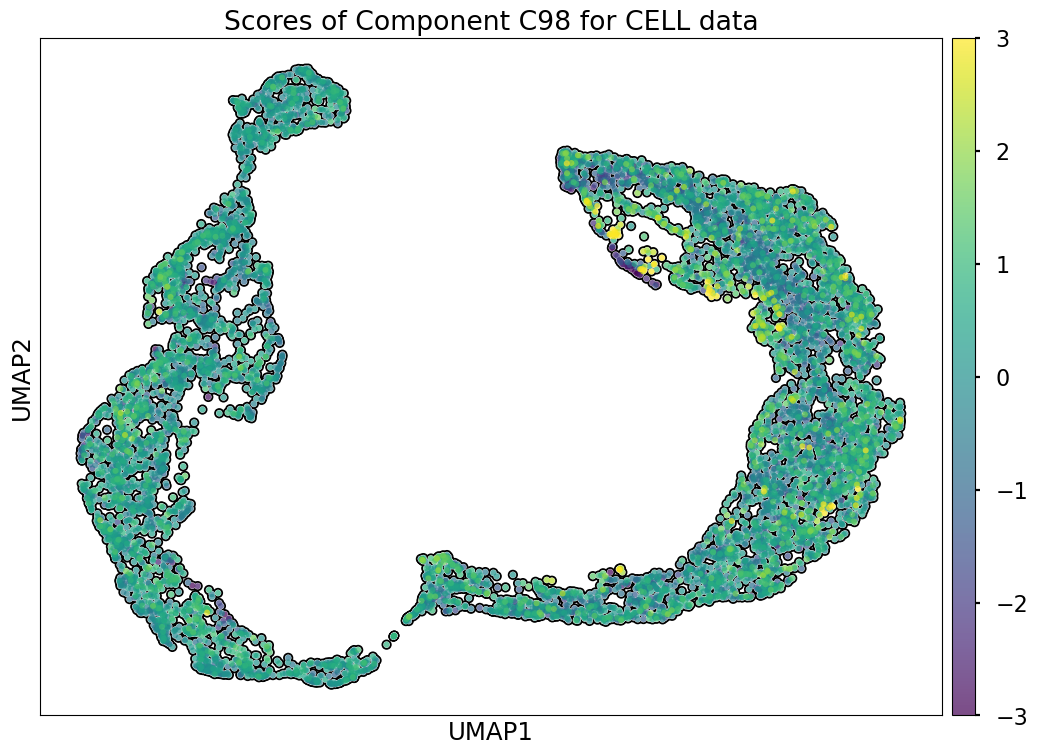

In [16]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True,
          save=f'scores_C{comp}_white.png', )

In [17]:
try:
    IRRELEVANT=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['IRRELEVANT']
except Exception as e:
    IRRELEVANT=0
try:
    POSITIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['POSITIVE']
except Exception as e:
    POSITIVE=0
try:
    NEGATIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['NEGATIVE']
except Exception as e:
     NEGATIVE=0

In [18]:
onlyrelevant = np.array( adata.obs[f'sda_cell_relevant_C{comp}'].copy() )
onlyrelevant[onlyrelevant=='IRRELEVANT']=None
adata.obs[f'sda_cell_relevantonly_C{comp}'] = onlyrelevant

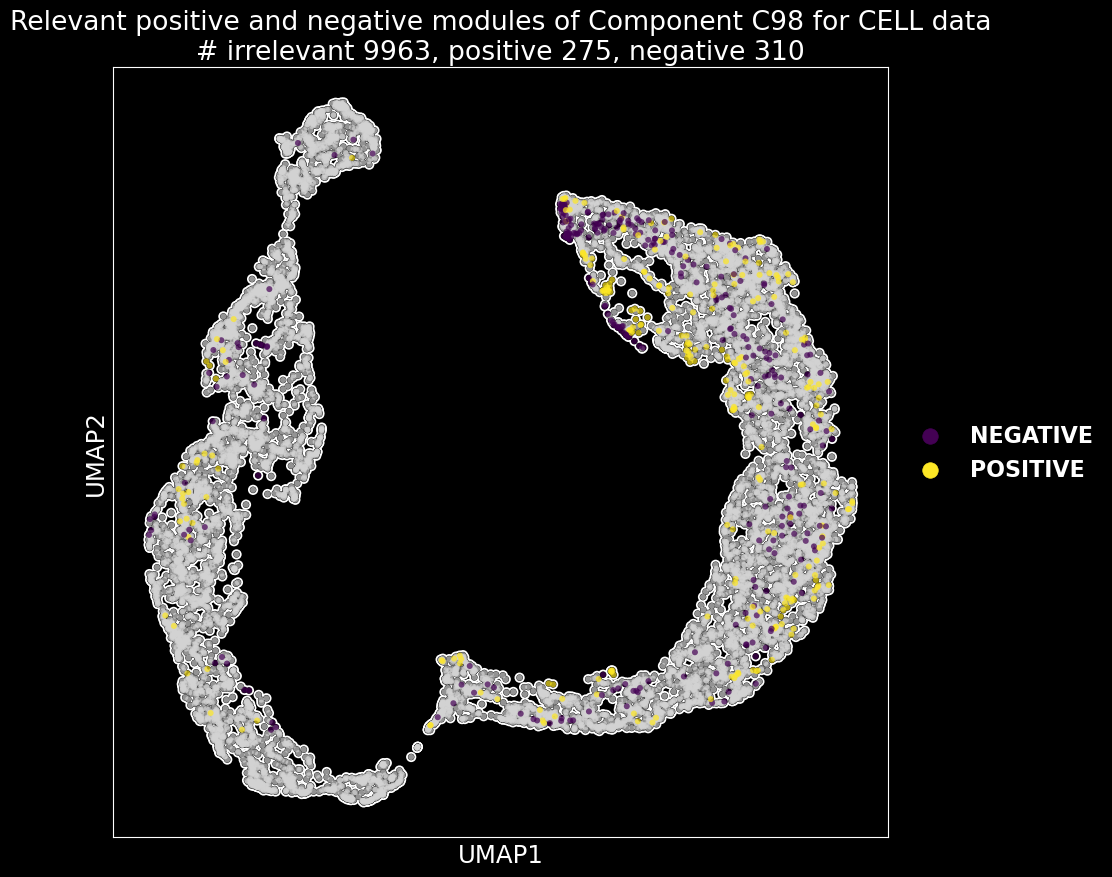

In [19]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data\n# irrelevant {IRRELEVANT}, positive {POSITIVE}, negative {NEGATIVE}', 
          size=75, add_outline=True, outline_color=['white','black'], palette='viridis',
          save=f'relevance_C{comp}_dark.png')

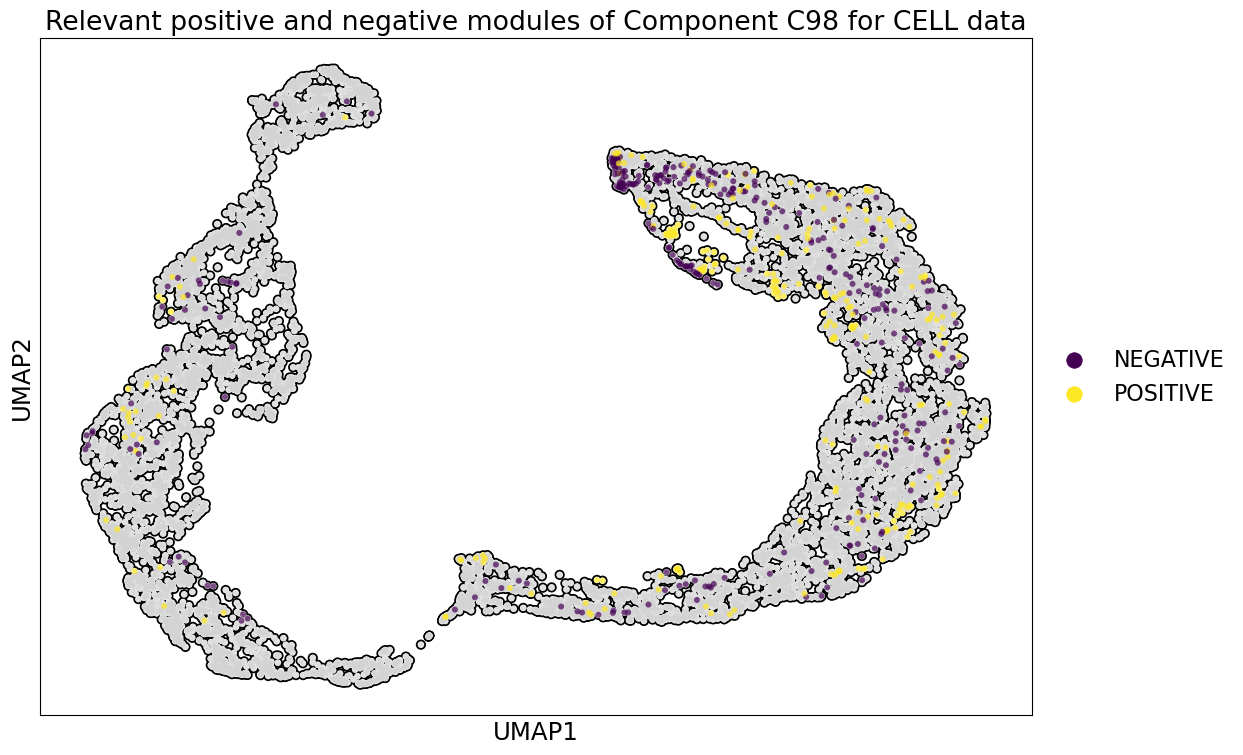

In [20]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data', palette='viridis',
          size=75, add_outline=True,
          save=f'relevance_C{comp}_white.png')

### mean and std of positive and negative cell scores for each batch

In [21]:
score_cells = adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}']
score_nuclei = adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}']

In [22]:
print( 'Positive scores nuclei - mean:', np.mean(score_nuclei[score_nuclei>1.5]), 'var:', np.std(score_nuclei[score_nuclei>1.5])  )
print( 'Positive scores cells  - mean:', np.mean(score_cells[score_cells>2]), 'var:', np.std(score_cells[score_cells>2])  )

Positive scores nuclei - mean: 2.2075656666666665 var: 0.8077834295125346
Positive scores cells  - mean: 2.4501115384615386 var: 0.42759581676816383


In [23]:
print( 'Negative scores nuclei - mean:', np.mean(score_nuclei[score_nuclei<-1.5]), 'var:', np.std(score_nuclei[score_nuclei<-1.5])  )
print( 'Negative scores cells  - mean:', np.mean(score_cells[score_cells<-2]), 'var:', np.std(score_cells[score_cells<-2])  )

Negative scores nuclei - mean: -1.891527245762712 var: 0.3869304511023855
Negative scores cells  - mean: -2.6906633783783787 var: 0.4933151243573094


### T-test to detect batch differences in a module

We check if positive/negative scores are specific for either cells or genes, so we can highlight that in our information output

In [24]:
import scipy

Two-sided test of positive scores of cells vs nuclei

In [25]:
scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])

Ttest_indResult(statistic=9.988551055354668, pvalue=2.7705461037780533e-23)

Two-sided test of negative scores of cells vs nuclei

In [26]:
scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

Ttest_indResult(statistic=-9.94379489638103, pvalue=4.254991356676122e-23)

Cells have more transcripts than nuclei and this is reflected in a bit higher/lower score in general, so we choose a strict threshold to avoid detecting batch differences where they are mostly due to technical causes

In [27]:
pos_stat, pos_p = scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])
neg_stat, neg_p = scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

batch_effect_pos='No'
batch_effect_neg='No'

if np.abs(pos_stat) > 10:
    batch_effect_pos='Yes'
print(f'Positive module batch differences: {batch_effect_pos}')
    
if np.abs(neg_stat) > 10:
    batch_effect_neg='Yes'
print(f'Negative module batch differences: {batch_effect_neg}')

Positive module batch differences: No
Negative module batch differences: No


<Axes: xlabel='SDA_cellscore_C98', ylabel='Count'>

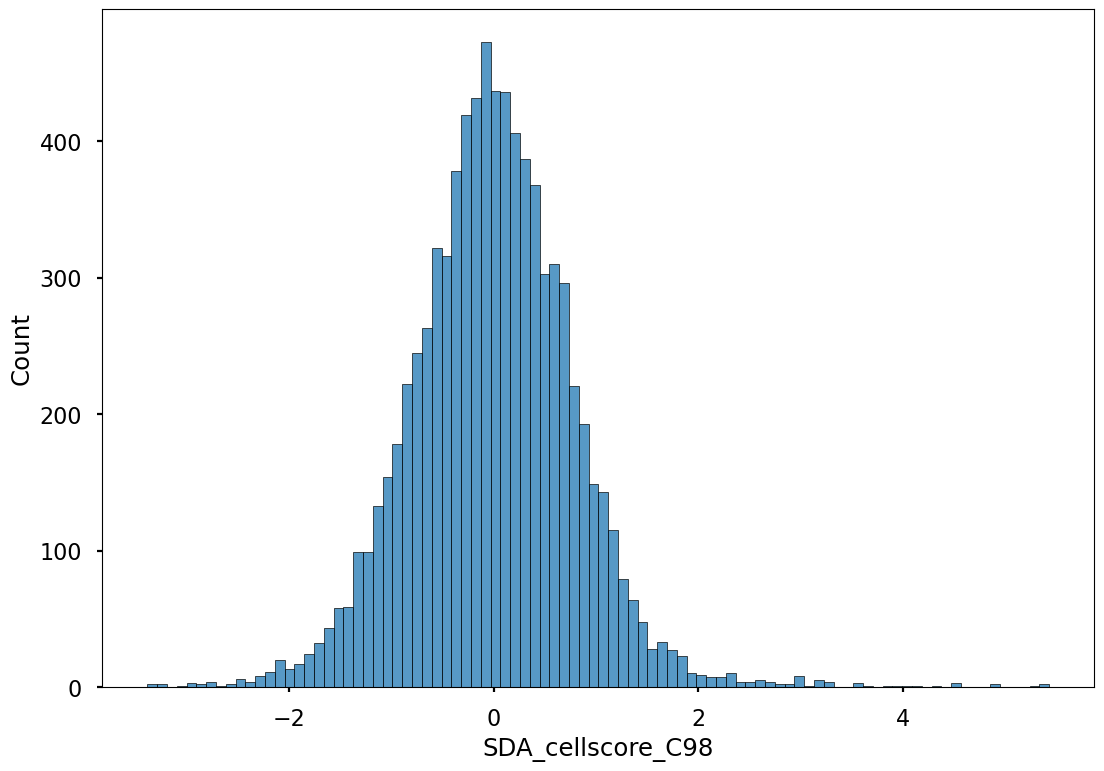

In [28]:
plt.rcParams['figure.figsize']=(6,6)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.histplot(adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}'])

<Axes: xlabel='SDA_cellscore_C98', ylabel='Count'>

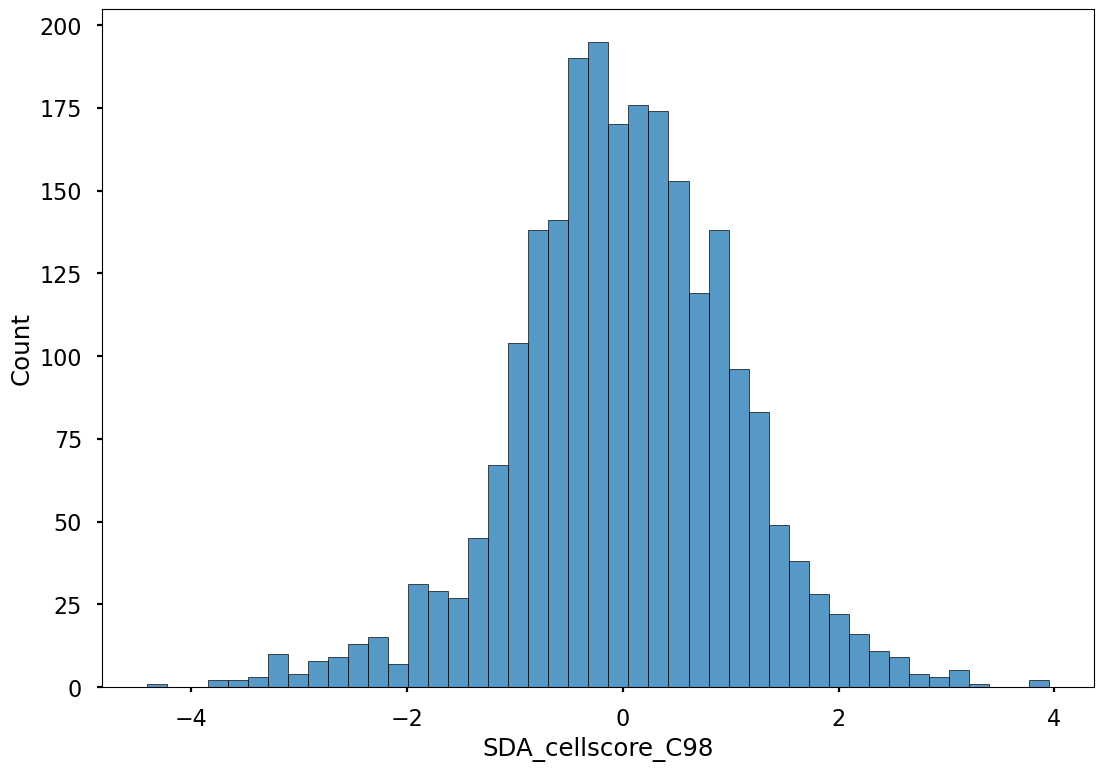

In [29]:
sns.histplot(adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'])

Genes significant for components (whole list printed to easy copy-pase for onlyne databases):

In [30]:
print(f'Genes significant for positive C{comp}:', adata[:,adata.var[f'sda_pos_C{comp}']].shape[1])

Genes significant for positive C98: 585


In [31]:
for i in adata[:,adata.var[f'sda_pos_C{comp}']].var_names:
    print(i)

MMEL1
ACTRT2
CHD5
SLC2A5
EFHD2
PLEKHM2
UBR4
PINK1
EIF4G3
KDM1A
SYF2
ZNF683
RNF19B
AZIN2
PHC2
STK40
MTF1
PABPC4
CITED4
SLFNL1
LOC742376
NSUN4
NRDC
LOC107966751
TCEANC2
MROH7
HOOK1
USP1
SERBP1
SSX2IP
BRDT
KIAA1324
RAP1A
DDX20
PPM1J
PHTF1
HIPK1
CSDE1
SPAG17
PLEKHO1
C1H1orf56
PBXIP1
MTX1
FDPS
ISG20L2
CFAP45
SDHC
CCDC181
SUCO
CEP350
ACBD6
SHCBP1L
TPR
CAMSAP2
KDM5B
CD46
KCNH1
SLC30A1
FAM71A
CENPF
ESRRG
EPRS
MIA3
CCDC185
TRIM17
LOC112206648
ADSS
DESI2
HNRNPU
AHCTF1
SH3YL1
ASAP2
LPIN1
PRR30
C2AH2orf16
CEBPZ
CDC42EP3
CALM2
PSME4
SPTBN1
CCDC88A
AFTPH
GFPT1
GMCL1
ALMS1
HK2
LOC107973527
KDM3A
LOC749343
GCC2
SNRNP200
TSGA10
EIF5B
NPAS2
ACTR3
BAZ2B
CCDC173
HNRNPA3
FSIP2
C2BH2orf69
BZW1
ZDBF2
KLF7
MAP2
TNP1
LOC740474
RETREG2
ABCB6
TUBA4A
ACSL3
CUL3
AGFG1
TRIP12
GIGYF2
ANKMY1
PPP1R7
THUMPD3
TADA3
HDAC11
SH3BP5
STT3B
SLC22A14
TTC21A
SETD2
DHX30
TMA7
UQCRC1
ZMYND10
DCAF1
FOXP1
GXYLT2
LOC107970711
LOC104005737
UBA5
TOPBP1
ZBTB38
DHX36
NLGN1
CCDC39
FXR1
MCF2L2
PSMD2
EIF4G1
LRCH3
GRK4
TACC3
GAK
CCDC96
CPEB

In [32]:
print(f'Genes significant for negative C{comp}:', adata[:,adata.var[f'sda_neg_C{comp}']].shape[1])

Genes significant for negative C98: 524


In [33]:
for i in adata[:,adata.var[f'sda_neg_C{comp}']].var_names:
    print(i)

AURKAIP1
CENPS
MRTO4
TEX46
ATP5IF1
HMGB4
MRPS15
DNALI1
AKIRIN1
YBX1
SVBP
RPS8
TEX38
SPATA6
RPL35A
DMRTB1
HSPB11
LOC742772
ZRANB2
GNG5
LRRC8B
GLMN
RPAP2
RPL5
LOC741368
VAV3
LOC107967559
TAF13
C1H1orf194
TMIGD3
LOC112208396
RNF115
SMCP
LELP1
TSACC
SPATA46
MPC2
CACYBP
LEMD1
LOC745816
SPATA17
LOC100613624
CEP170
LOC107970870
RPS7
KLF11
SF3B6
ATRAID
NDUFAF7
SRSF7
GEMIN6
MORN2
ATP6V1E2
GTF2A1L
RPS27A
NFU1
ZNF638
RNF181
IMMT
LOC112208191
LOC107973562
ANKRD36C
LOC741694
RPL31
CCDC138
KCNH7
SCN1A
SCRN3
TTN
CCDC141
INPP1
SUMO1
EEF1B2
LOC100612604
SPATA3
DIS3L2
LOC470685
LOC749543
EMC3
FANCD2OS
RPL32
LSM3
NKIRAS1
RPL15
LOC107970599
EIF1B
RPL14
LOC460305
ZDHHC3
LOC104005558
NDUFAF3
LOC100612705
RPL29
SPCS1
CGGBP1
RPL24
CCDC54
NDUFB4
FAM162A
ROPN1
ROPN1B
LOC100610772
C3H3orf22
STAG1
RNF7
LOC735610
GYG1
SERP1
SSR3
MLF1
TRIM59
LOC107970832
LOC107970837
MRPL47
DCUN1D1
HRASLS
NCBP2
STIM2
RPL9
LOC104006067
USO1
IGFBP7
SPINK2
CEP135
PDCL2
USP46
COX7B2
H2AFZ
UBE2D3
LOC101059134
LOC104006211
SCOC
LOC461536

#### Cells scores by cluster

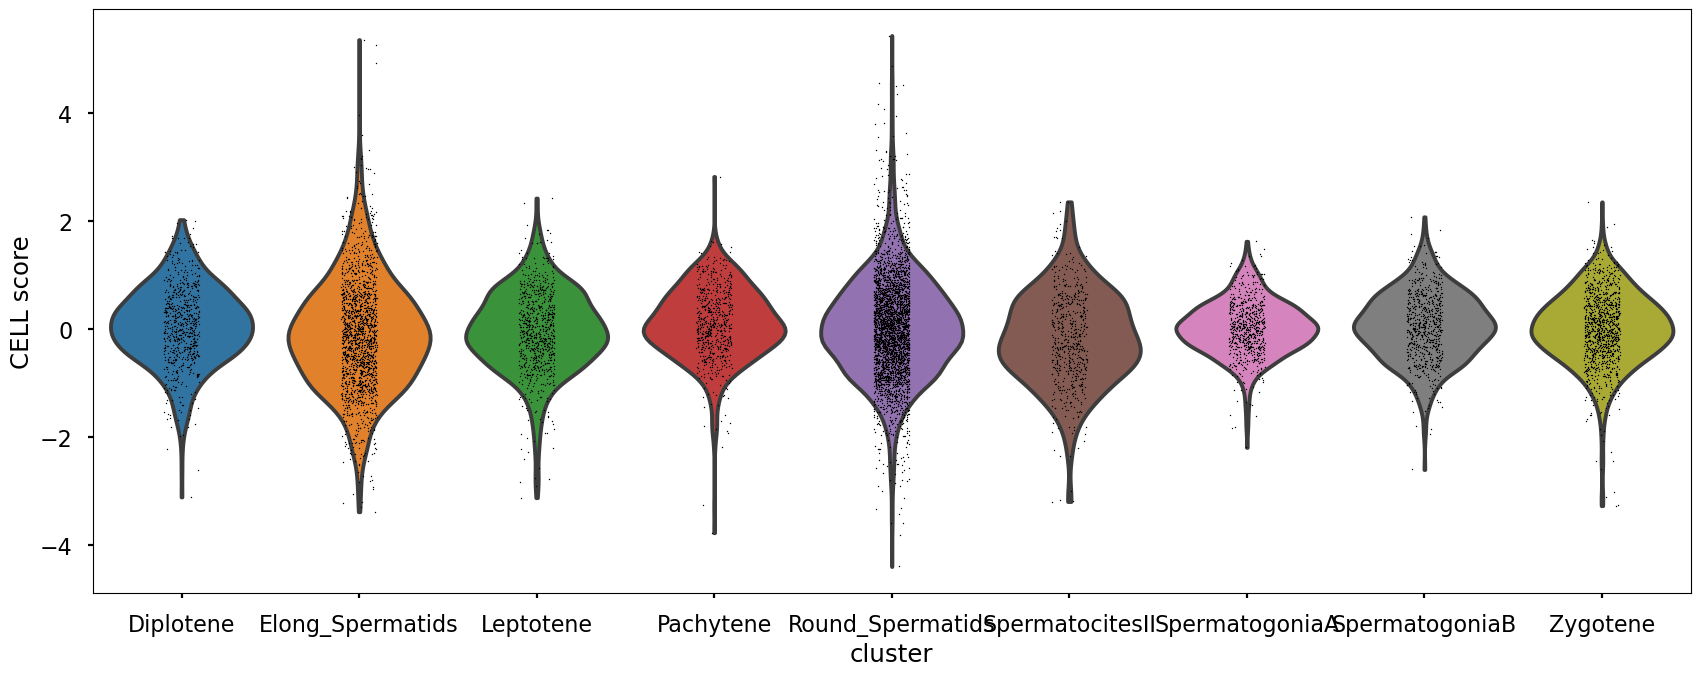

In [34]:
plt.rcParams['figure.figsize']=(16,8)
sc.pl.violin(adata, 
             groupby='spermatogenesis', keys=f'SDA_cellscore_C{comp}',
             title=f'CELLS score for SDA component C{comp}',
             xlabel='cluster', ylabel='CELL score')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'SpermatogoniaA'),
  Text(1, 0, 'SpermatogoniaB'),
  Text(2, 0, 'Leptotene'),
  Text(3, 0, 'Zygotene'),
  Text(4, 0, 'Pachytene'),
  Text(5, 0, 'Diplotene'),
  Text(6, 0, 'SpermatocitesII'),
  Text(7, 0, 'Round_Spermatids'),
  Text(8, 0, 'Elong_Spermatids')])

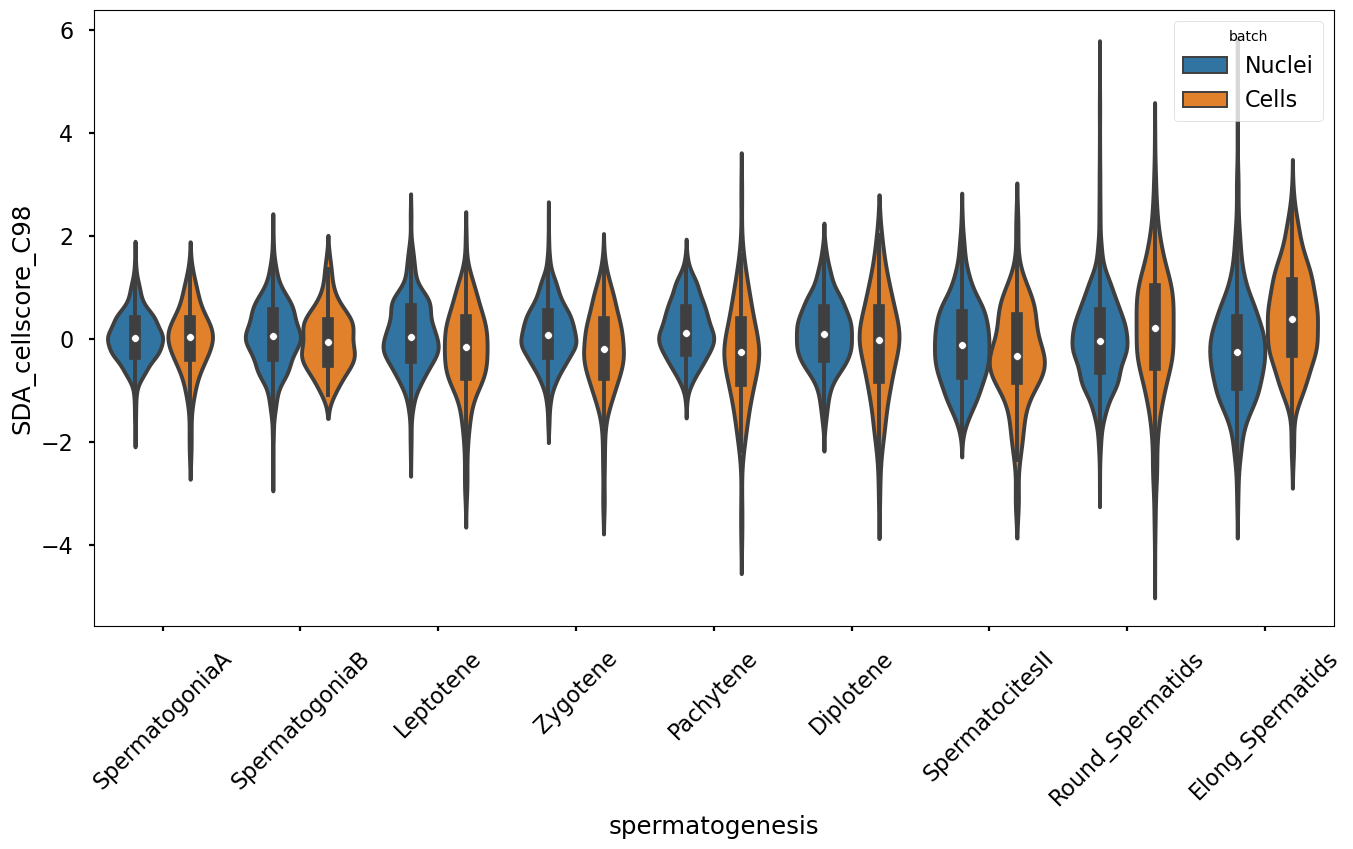

In [35]:
plt.rcParams['figure.figsize']=(16,8)
sns.violinplot(x='spermatogenesis', y=f'SDA_cellscore_C{comp}', hue='batch', data=adata.obs, 
               order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids'])
plt.xticks(rotation=45)

#### Cell scores by pseudotimes and relative threshold lines

In [36]:
score_neg = -2 #min( -2, np.quantile(A[int(comp)], .1) )
score_pos = 2 #max( +2, np.quantile(A[int(comp)], .9) )

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C98')

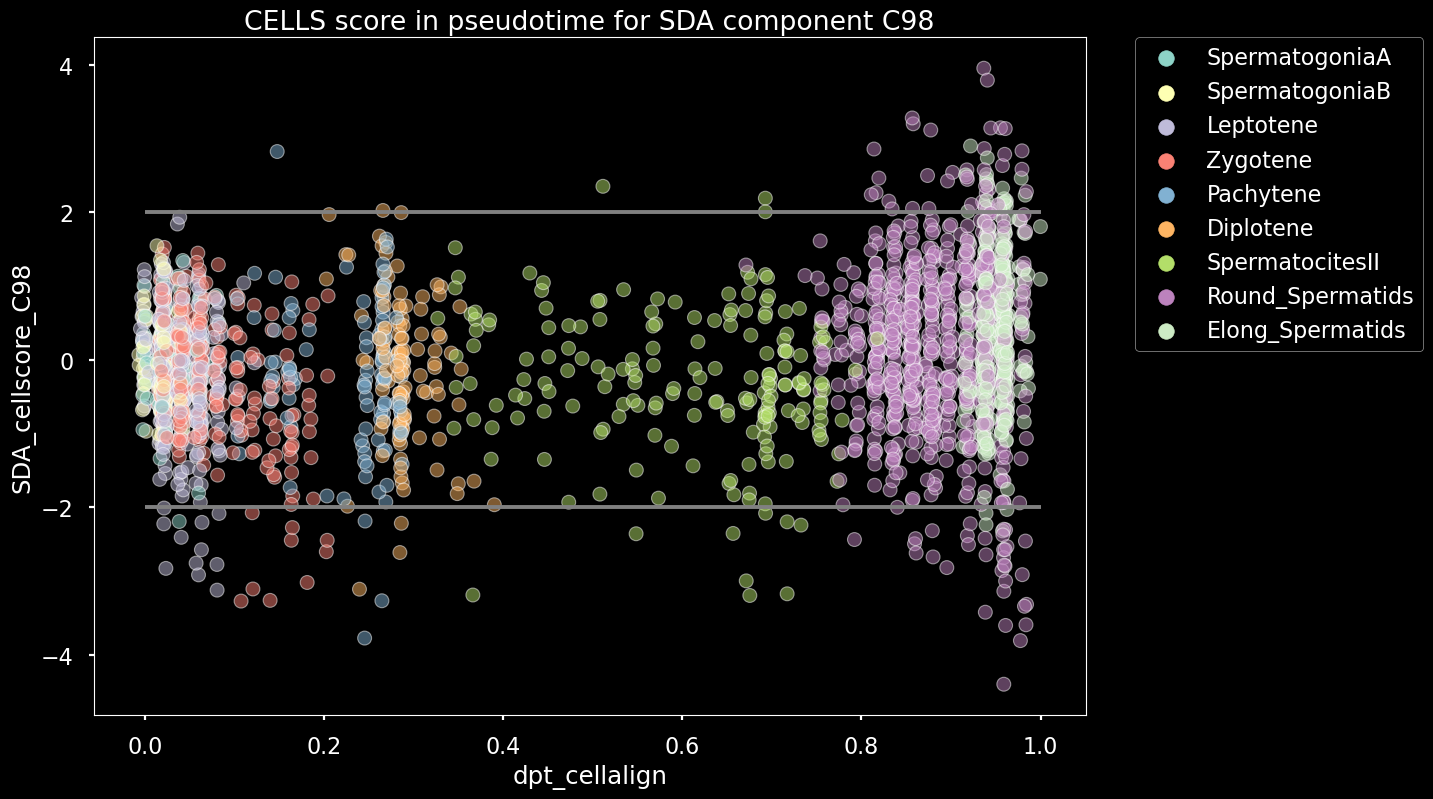

In [37]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.5, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C98')

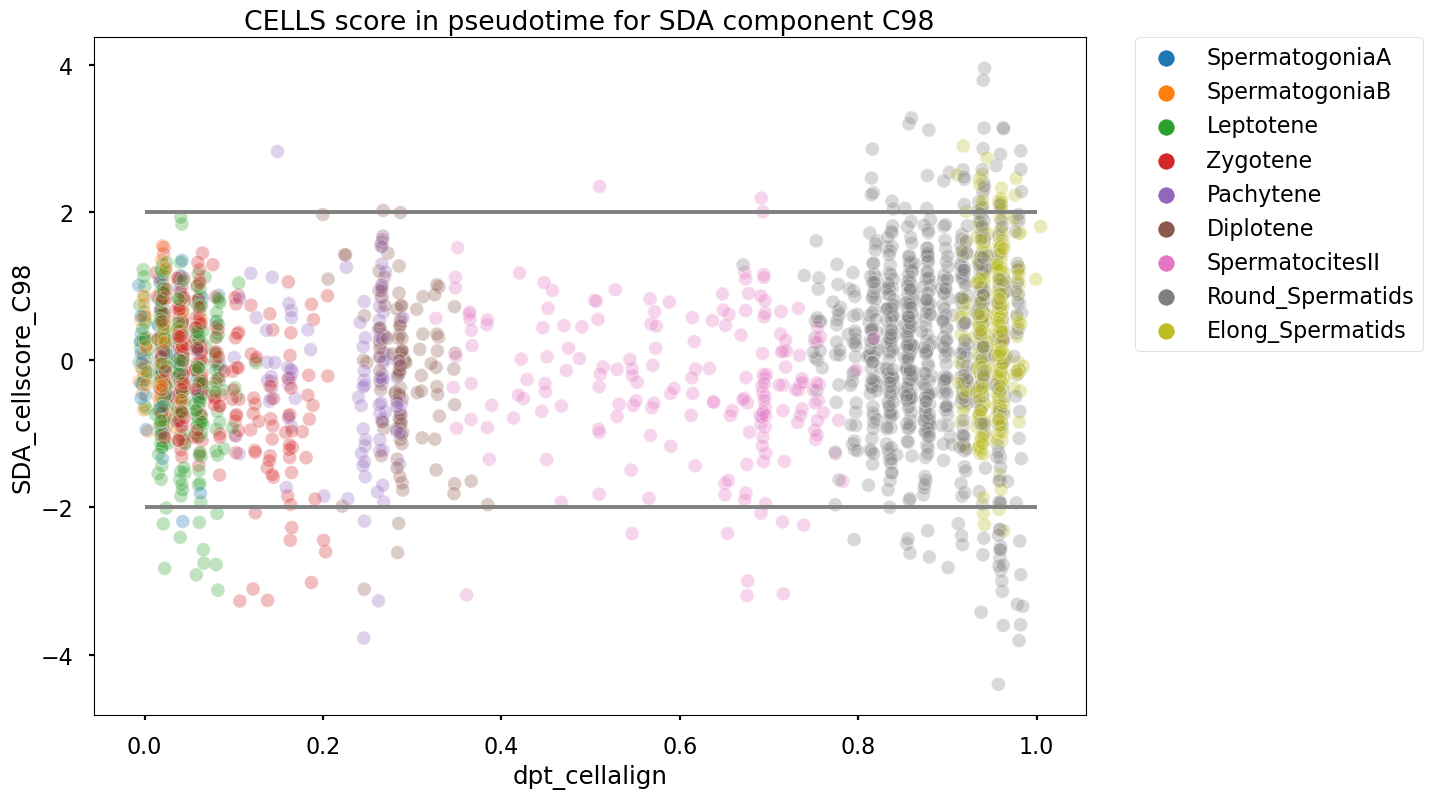

In [38]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.3, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C98')

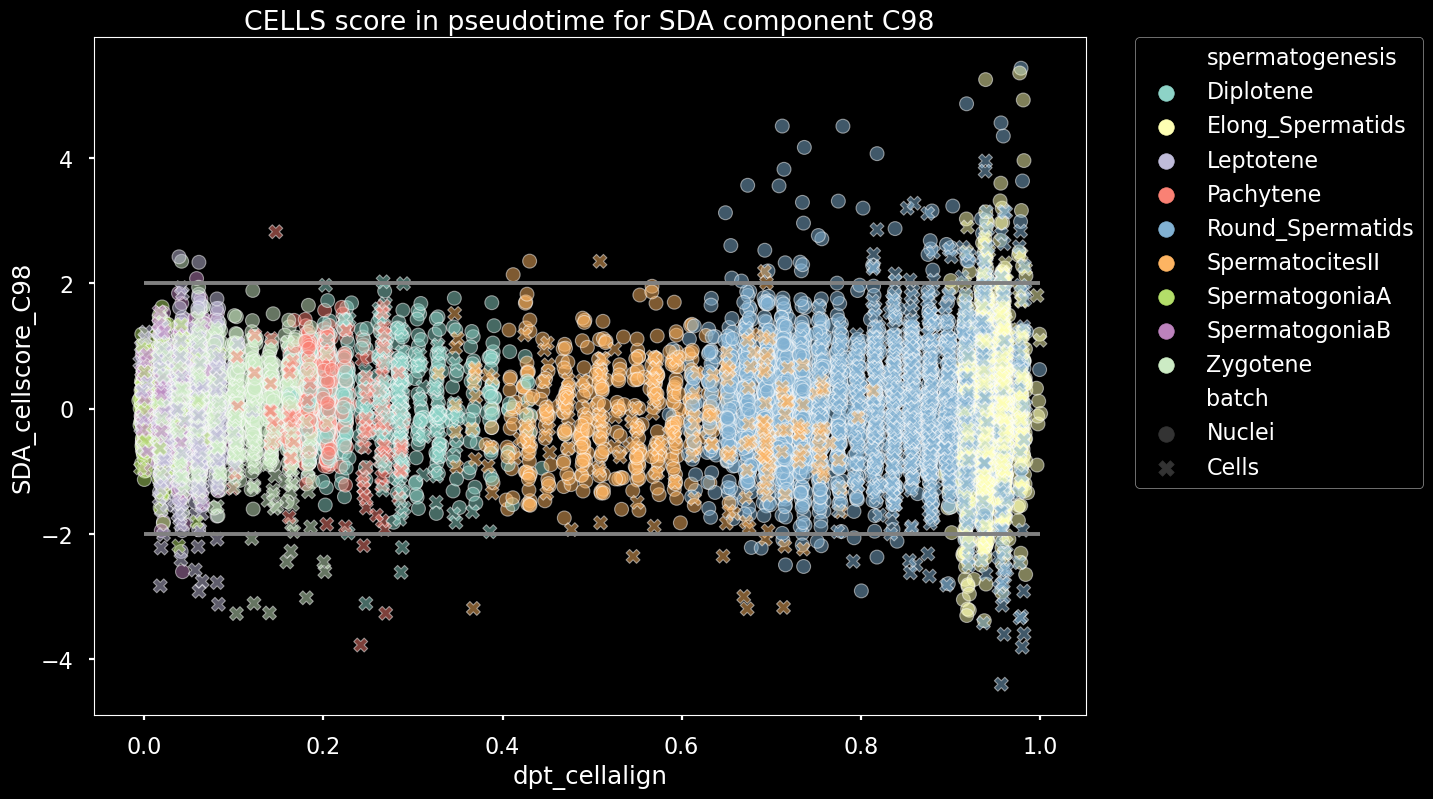

In [39]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.5, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C98')

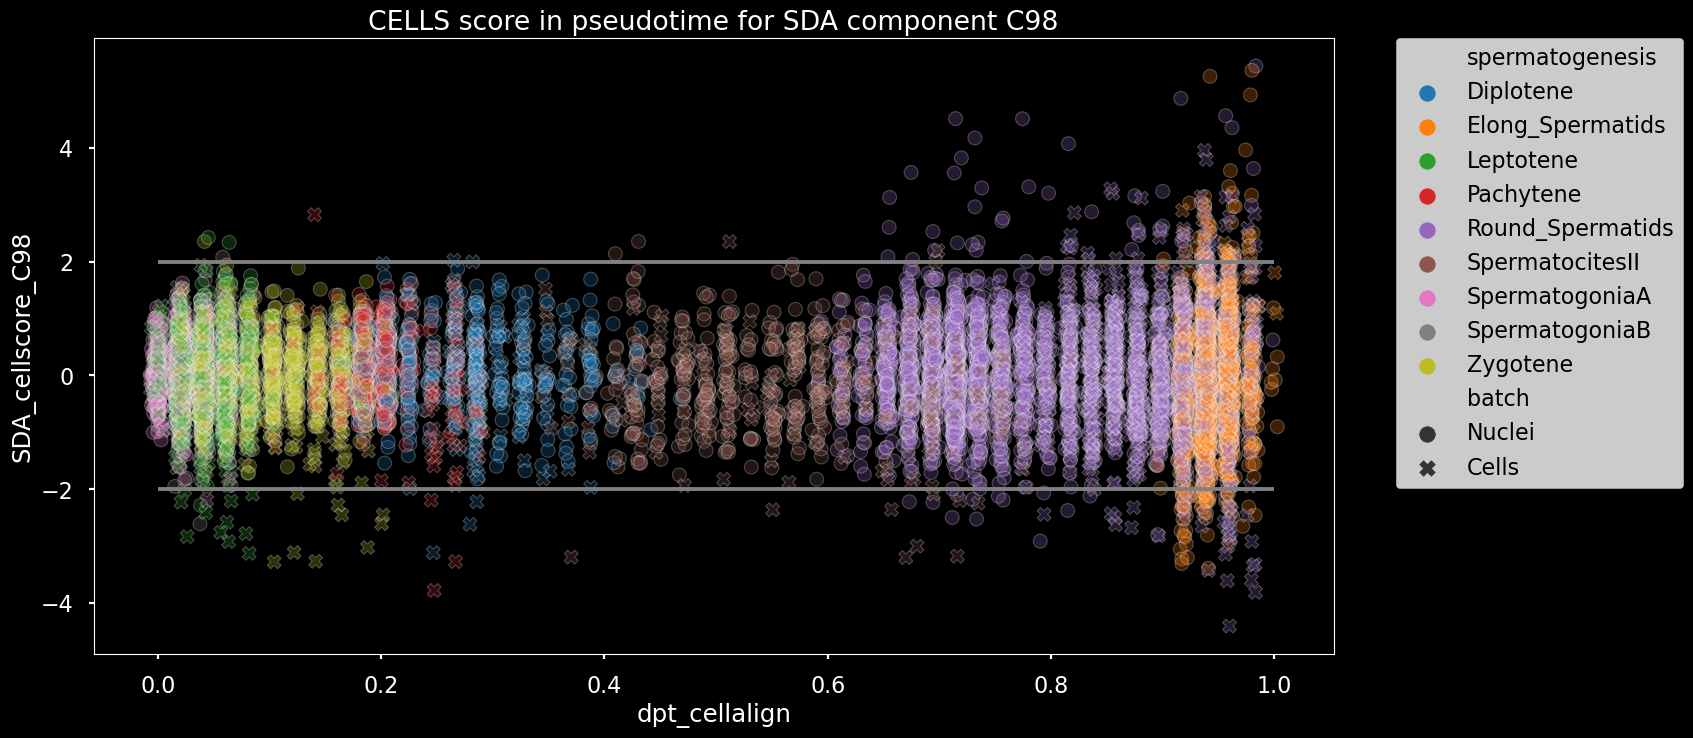

In [40]:
plt.rcParams['figure.figsize']=(16,8)
fig, ax = plt.subplots(1)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.25, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

## Gene set enrichment analysis

In [41]:
import gseapy as gp

In [42]:
!mkdir -p ./enrichment

In [43]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [44]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [45]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Amyotrophic lateral sclerosis,28/364,3.554785e-06,8.495936e-04,0,0,2.854428,35.815131,DNAH8;ACTB;KLC3;ATP5F1B;TUBA3C;PSMD2;KIF5B;RB1...
239,GO_Cellular_Component_2023,Nucleus (GO:0005634),205/4487,1.215584e-12,2.978181e-10,0,0,1.906552,52.307770,HDAC11;HNRNPU;SMC5;ACTB;DCAF1;TRIM28;PSMD2;GPB...
240,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,222/5175,5.048816e-11,6.184800e-09,0,0,1.785691,42.337459,HDAC11;HNRNPU;SMC5;ACTB;DCAF1;TRIM28;PSMD2;GPB...
241,GO_Cellular_Component_2023,Spindle (GO:0005819),21/210,1.015160e-06,8.290474e-05,0,0,3.787628,52.271026,CTDP1;NUMA1;CUL3;USP44;SHCBP1L;CLTC;HNRNPU;WDR...
484,Human_Gene_Atlas,TestisIntersitial,74/568,1.091606e-27,7.204602e-26,0,0,5.546614,344.345717,TSKS;CALR3;SPAG17;KDM5B;AHCTF1;USP32;CEP164;CE...
485,Human_Gene_Atlas,Testis,37/384,2.279385e-10,7.521971e-09,0,0,3.710196,82.373565,TSKS;KDM5B;ANKLE2;CATSPER3;CETN1;ACTL7A;MEPCE;...
486,Human_Gene_Atlas,TestisGermCell,32/314,9.557591e-10,2.102670e-08,0,0,3.926077,81.538789,CALR3;CUL3;ACTL7B;CETN3;CEP164;KLHL10;DDX20;WD...


In [46]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [47]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None)

In [48]:
table_pos = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [49]:
table_pos['Component'] = f'{comp}P'

In [50]:
table_pos['Batch diff'] = batch_effect_pos

In [51]:
table_pos['N cells'] = POSITIVE

In [52]:
table_pos

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Amyotrophic lateral sclerosis,28/364,8.495936e-04,2.854428,35.815131,DNAH8;ACTB;KLC3;ATP5F1B;TUBA3C;PSMD2;KIF5B;RB1...,98P,No,275
239,GO_Cellular_Component_2023,Nucleus (GO:0005634),205/4487,2.978181e-10,1.906552,52.307770,HDAC11;HNRNPU;SMC5;ACTB;DCAF1;TRIM28;PSMD2;GPB...,98P,No,275
240,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,222/5175,6.184800e-09,1.785691,42.337459,HDAC11;HNRNPU;SMC5;ACTB;DCAF1;TRIM28;PSMD2;GPB...,98P,No,275
241,GO_Cellular_Component_2023,Spindle (GO:0005819),21/210,8.290474e-05,3.787628,52.271026,CTDP1;NUMA1;CUL3;USP44;SHCBP1L;CLTC;HNRNPU;WDR...,98P,No,275
484,Human_Gene_Atlas,TestisIntersitial,74/568,7.204602e-26,5.546614,344.345717,TSKS;CALR3;SPAG17;KDM5B;AHCTF1;USP32;CEP164;CE...,98P,No,275
485,Human_Gene_Atlas,Testis,37/384,7.521971e-09,3.710196,82.373565,TSKS;KDM5B;ANKLE2;CATSPER3;CETN1;ACTL7A;MEPCE;...,98P,No,275
486,Human_Gene_Atlas,TestisGermCell,32/314,2.102670e-08,3.926077,81.538789,CALR3;CUL3;ACTL7B;CETN3;CEP164;KLHL10;DDX20;WD...,98P,No,275


In [53]:
table_pos.to_csv(f'enrichment/enrichr_C{comp}P.csv', header=False, index_label=False, index=None, sep='\t')

In [54]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [55]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [56]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Ribosome,34/158,1.193997e-21,2.304415e-19,0,0,10.828966,521.706901,RPL5;RPL30;MRPS15;RPL32;RPL31;RPL12;MRPL36;RPL...
1,KEGG_2021_Human,Coronavirus disease,30/232,5.631589e-13,5.434484e-11,0,0,5.794484,163.434673,RPL5;RPL30;RPL32;RPL31;RPL12;RPL10A;RPL9;RPL6;...
2,KEGG_2021_Human,Parkinson disease,26/249,2.297380e-09,1.477981e-07,0,0,4.507519,89.661296,NDUFB8;NDUFB10;NDUFB6;NDUFA12;NDUFB4;UQCR10;CO...
3,KEGG_2021_Human,Oxidative phosphorylation,17/133,7.439915e-08,3.589759e-06,0,0,5.596137,91.853990,ATP5PF;NDUFB8;NDUFB10;NDUFB6;NDUFA12;NDUFB4;ND...
4,KEGG_2021_Human,Huntington disease,26/306,1.581696e-07,6.105348e-06,0,0,3.579289,56.050220,NDUFB8;NDUFB10;NDUFB6;NDUFA12;NDUFB4;UQCR10;CO...
5,KEGG_2021_Human,Prion disease,23/273,9.519918e-07,3.062240e-05,0,0,3.530523,48.949675,ATP5PF;NDUFB8;NDUFB10;NDUFB6;NDUFA12;NDUFB4;ND...
6,KEGG_2021_Human,Diabetic cardiomyopathy,19/203,1.778619e-06,4.903907e-05,0,0,3.944770,52.227462,ATP5PF;NDUFB8;NDUFB10;NDUFB6;NDUFA12;NDUFB4;ND...
7,KEGG_2021_Human,Thermogenesis,20/232,3.417747e-06,8.245314e-05,0,0,3.605870,45.385388,ATP5PF;NDUFB8;NDUFB10;NDUFB6;NDUFA12;NDUFB4;ND...
8,KEGG_2021_Human,Pathways of neurodegeneration,30/475,9.188448e-06,1.970412e-04,0,0,2.597143,30.120534,NDUFB8;NDUFB6;NDUFB10;NDUFA12;NDUFB4;UQCR10;CO...
9,KEGG_2021_Human,Amyotrophic lateral sclerosis,25/364,1.262432e-05,2.436494e-04,0,0,2.828223,31.902029,NDUFB8;NDUFB10;NDUFB6;NDUFA12;NDUFB4;UQCR10;CO...


In [57]:
table_neg = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [58]:
table_neg['Component'] = f'{comp}N'

In [59]:
table_neg['Batch diff'] = batch_effect_neg

In [60]:
table_neg['N cells'] = NEGATIVE

In [61]:
table_neg

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Ribosome,34/158,2.304415e-19,10.828966,521.706901,RPL5;RPL30;MRPS15;RPL32;RPL31;RPL12;MRPL36;RPL...,98N,No,310
1,KEGG_2021_Human,Coronavirus disease,30/232,5.434484e-11,5.794484,163.434673,RPL5;RPL30;RPL32;RPL31;RPL12;RPL10A;RPL9;RPL6;...,98N,No,310
2,KEGG_2021_Human,Parkinson disease,26/249,1.477981e-07,4.507519,89.661296,NDUFB8;NDUFB10;NDUFB6;NDUFA12;NDUFB4;UQCR10;CO...,98N,No,310
3,KEGG_2021_Human,Oxidative phosphorylation,17/133,3.589759e-06,5.596137,91.853990,ATP5PF;NDUFB8;NDUFB10;NDUFB6;NDUFA12;NDUFB4;ND...,98N,No,310
4,KEGG_2021_Human,Huntington disease,26/306,6.105348e-06,3.579289,56.050220,NDUFB8;NDUFB10;NDUFB6;NDUFA12;NDUFB4;UQCR10;CO...,98N,No,310
5,KEGG_2021_Human,Prion disease,23/273,3.062240e-05,3.530523,48.949675,ATP5PF;NDUFB8;NDUFB10;NDUFB6;NDUFA12;NDUFB4;ND...,98N,No,310
6,KEGG_2021_Human,Diabetic cardiomyopathy,19/203,4.903907e-05,3.944770,52.227462,ATP5PF;NDUFB8;NDUFB10;NDUFB6;NDUFA12;NDUFB4;ND...,98N,No,310
7,KEGG_2021_Human,Thermogenesis,20/232,8.245314e-05,3.605870,45.385388,ATP5PF;NDUFB8;NDUFB10;NDUFB6;NDUFA12;NDUFB4;ND...,98N,No,310
8,KEGG_2021_Human,Pathways of neurodegeneration,30/475,1.970412e-04,2.597143,30.120534,NDUFB8;NDUFB6;NDUFB10;NDUFA12;NDUFB4;UQCR10;CO...,98N,No,310
9,KEGG_2021_Human,Amyotrophic lateral sclerosis,25/364,2.436494e-04,2.828223,31.902029,NDUFB8;NDUFB10;NDUFB6;NDUFA12;NDUFB4;UQCR10;CO...,98N,No,310


In [62]:
table_neg.to_csv(f'enrichment/enrichr_C{comp}N.csv', header=False, index_label=False, index=None, sep='\t')

## Plot genes average expression for positive and negative module

In [63]:
!mkdir -p ./plots

In [64]:
adata.layers

Layers with keys: SCT_counts, correct_counts, raw_counts, scaled_counts, spliced, unspliced

In [65]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [66]:
adata.obs[f'module_pos_C{comp}'] = np.array( np.mean(adata[:,genes].layers['scaled_counts'], 1) )

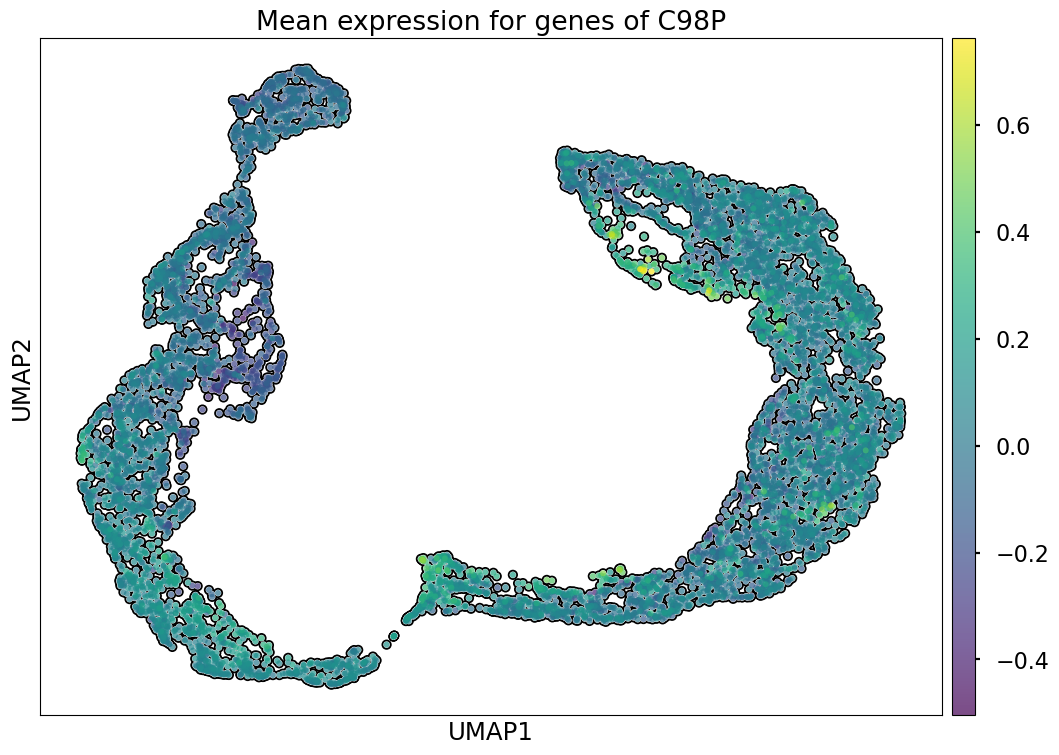

In [67]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}P_white.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

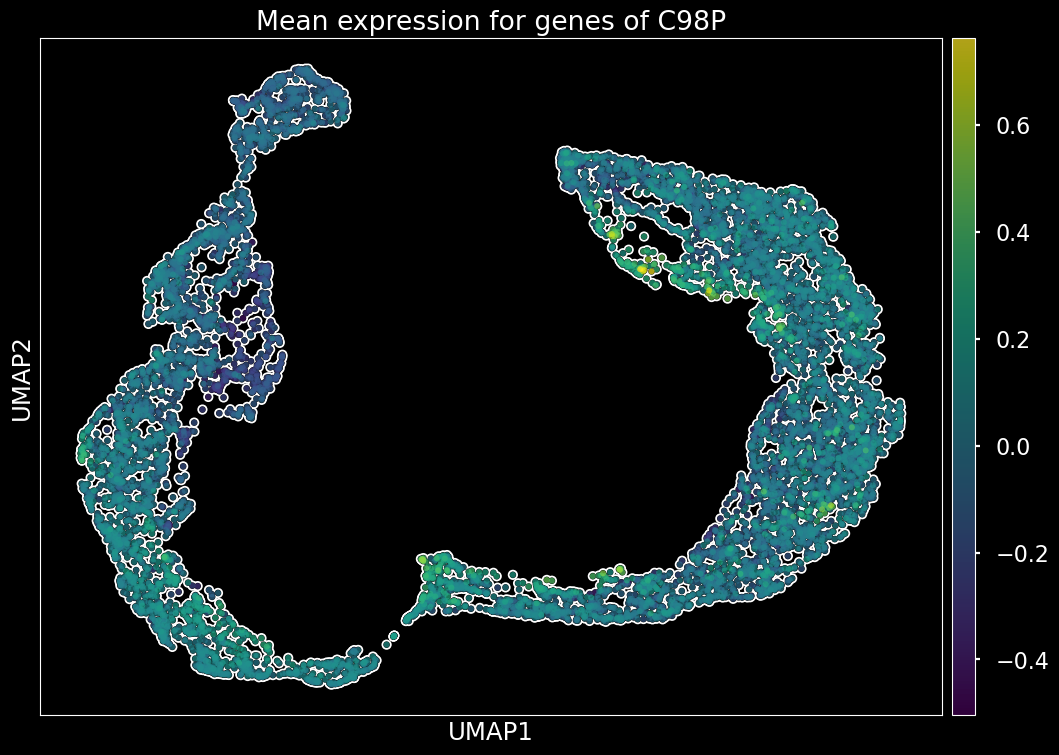

In [68]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}P_dark.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

In [69]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [70]:
adata.obs[f'module_neg_C{comp}'] = np.array( np.mean(adata[:,genes].layers['SCT_counts'], 1) )

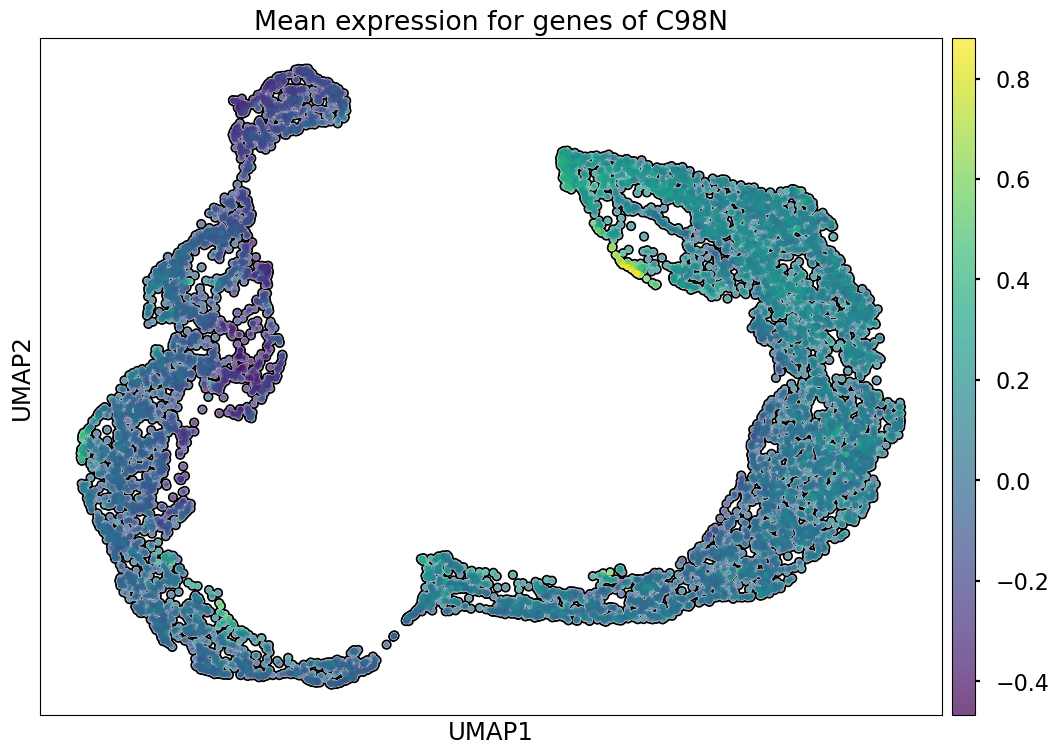

In [71]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}N_white.png',
           title=f'Mean expression for genes of C{comp}N', size=75)

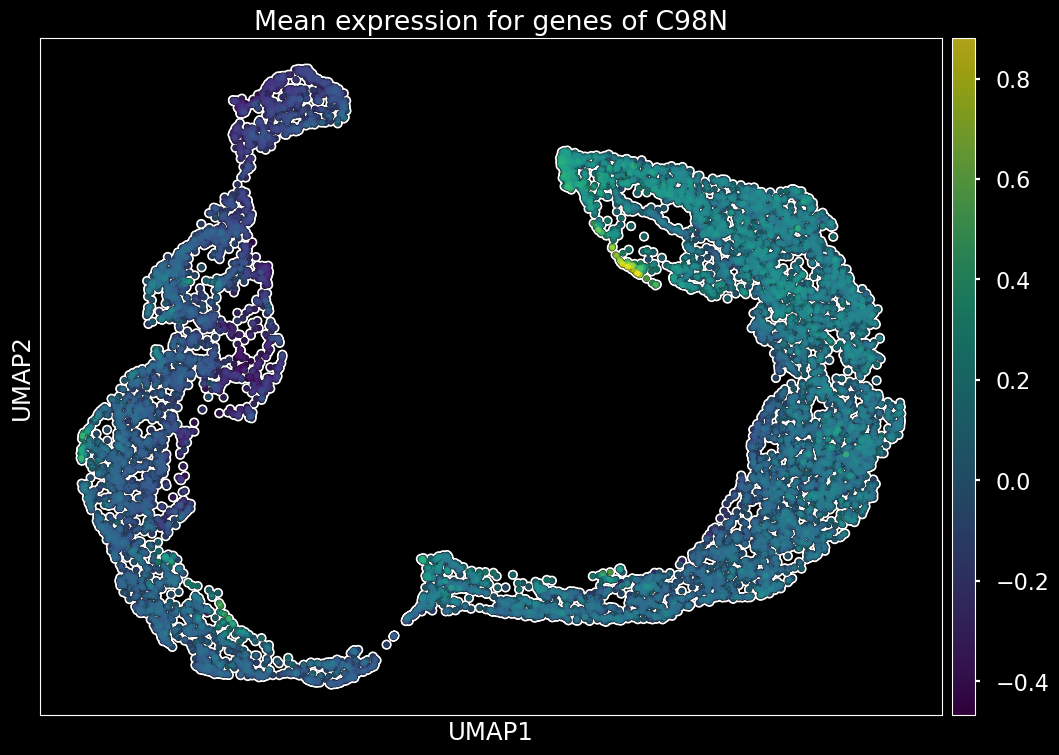

In [72]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}N_dark.png',
           title=f'Mean expression for genes of C{comp}N', size=75)